#  Projet R U Shiny : Visualisation interactive d’un jeu de données réel

## Introduction

Ce projet a pour objectif de **construire un dashboard dynamique** permettant d’explorer et de visualiser en temps réel un jeu de données public, tout en mettant en œuvre des techniques avancées de **nettoyage, transformation et analyse exploratoire**.

Nous avons choisi le dataset **`AAP_2022_city_v9.csv`**, qui contient des informations relatives à la qualité de l'air sur plusieurs zones géographique. Ce fichier présente une richesse d’informations mais aussi plusieurs défis typiques du travail de data analyst :
- valeurs manquantes,
- données mal formatées,
- présence de variables numériques et catégorielles à structurer.

Grâce à ce projet, nous allons :
- Appliquer les techniques de **nettoyage et de transformation de données** en R,
- Créer une **interface interactive** permettant de filtrer, explorer et visualiser les données,
- Présenter les résultats sous forme de **dashboard R Shiny**, et les mettre à disposition via un dépôt GitHub.


## Orientation stratégique du projet

Nous avons axé la thématique centrale de notre analyse autour de la question suivante :

**"Comment la pollution de l’air a-t-elle évolué dans les pays de la région européenne (zone géographique retenue?) entre 2015 et 2019 ?"**

L'objectif est de suivre les niveaux de concentration des principaux polluants atmosphériques — **PM2.5**, **PM10** et **NO2** — sur une période de cinq ans, et ce, à l’échelle des **pays et des villes** de la région européenne.

### Questions clés auxquelles nous allons tenter de répondre :

- Les niveaux de pollution ont-ils diminué dans certaines régions ?
- Quels pays ont enregistré une amélioration ou, au contraire, une dégradation notable de la qualité de l'air ?
- Les évolutions observées sont-elles cohérentes avec les politiques environnementales mises en place par les pays concernés ?



## Chargement des librairies 

In [39]:
install.packages("plotly")
install.packages("corrplot")
install.packages("janitor")


le package 'plotly' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\ndiay\AppData\Local\Temp\Rtmpakx1MV\downloaded_packages


Warning message:
"le package 'corrplot' est en cours d'utilisation et ne sera pas installé"
installation de la dépendance 'snakecase'




le package 'snakecase' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'janitor' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\ndiay\AppData\Local\Temp\Rtmpakx1MV\downloaded_packages


In [ ]:
library("corrplot")
library("dplyr")
library("tidyr")

## 1. Exploration initiale du fichier

In [6]:
# chargement des données
data <- read.csv("C:/Users/ndiay/Desktop/lptf/projets/IA/DATA_ANALYSIS/R_RSTUDIO/R_U_shiny/AAP_2022_city_v9.csv")
#sxploration et statistiques descriptives
View(data)
head(data)              
dim(data)             
str(data)             
summary(data)      

WHO.Region,ISO3,WHO.Country.Name,City.or.Locality,Measurement.Year,PM2.5..μg.m3.,PM10..μg.m3.,NO2..μg.m3.,PM25.temporal.coverage....,PM10.temporal.coverage....,NO2.temporal.coverage....,Reference,Number.and.type.of.monitoring.stations,Version.of.the.database,Status
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>
Eastern Mediterranean Region,AFG,Afghanistan,Kabul,2019,"119,77",,,18,,,"U.S. Department of State, United States Environmental Protection Agency",NA,2022,NA
European Region,ALB,Albania,Durres,2015,,"17,65","26,63",,,"83,96118721",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Durres,2016,"14,32","24,56","24,78",,,"87,93260474",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2015,,,"23,96",,,"97,85388128",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2016,,,"26,26",,,"96,0496357",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2017,,,"24,7",,,"89,29223744",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Korce,2015,"30,34","45,31",,,,,European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Korce,2016,"28,64","40,21","12,52",,,"89,28734062",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Vlore,2014,,"15,25",,,,,European Environment Agency (downloaded in 2021),NA,2022,NA


,WHO.Region,ISO3,WHO.Country.Name,City.or.Locality,Measurement.Year,PM2.5..μg.m3.,PM10..μg.m3.,NO2..μg.m3.,PM25.temporal.coverage....,PM10.temporal.coverage....,NO2.temporal.coverage....,Reference,Number.and.type.of.monitoring.stations,Version.of.the.database,Status
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>
1,Eastern Mediterranean Region,AFG,Afghanistan,Kabul,2019,"119,77",,,18,,,"U.S. Department of State, United States Environmental Protection Agency",NA,2022,NA
2,European Region,ALB,Albania,Durres,2015,,"17,65","26,63",,,"83,96118721",European Environment Agency (downloaded in 2021),NA,2022,NA
3,European Region,ALB,Albania,Durres,2016,"14,32","24,56","24,78",,,"87,93260474",European Environment Agency (downloaded in 2021),NA,2022,NA
4,European Region,ALB,Albania,Elbasan,2015,,,"23,96",,,"97,85388128",European Environment Agency (downloaded in 2021),NA,2022,NA
5,European Region,ALB,Albania,Elbasan,2016,,,"26,26",,,"96,0496357",European Environment Agency (downloaded in 2021),NA,2022,NA
6,European Region,ALB,Albania,Elbasan,2017,,,"24,7",,,"89,29223744",European Environment Agency (downloaded in 2021),NA,2022,NA


[1] 32191    15

'data.frame':	32191 obs. of  15 variables:
 $ WHO.Region                            : chr  "Eastern Mediterranean Region" "European Region" "European Region" "European Region" ...
 $ ISO3                                  : chr  "AFG" "ALB" "ALB" "ALB" ...
 $ WHO.Country.Name                      : chr  "Afghanistan" "Albania" "Albania" "Albania" ...
 $ City.or.Locality                      : chr  "Kabul" "Durres" "Durres" "Elbasan" ...
 $ Measurement.Year                      : int  2019 2015 2016 2015 2016 2017 2015 2016 2014 2015 ...
 $ PM2.5..μg.m3.                         : chr  "119,77" "" "14,32" "" ...
 $ PM10..μg.m3.                          : chr  "" "17,65" "24,56" "" ...
 $ NO2..μg.m3.                           : chr  "" "26,63" "24,78" "23,96" ...
 $ PM25.temporal.coverage....            : chr  "18" "" "" "" ...
 $ PM10.temporal.coverage....            : chr  "" "" "" "" ...
 $ NO2.temporal.coverage....             : chr  "" "83,96118721" "87,93260474" "97,85388128" ...
 $ 

  WHO.Region            ISO3           WHO.Country.Name   City.or.Locality  
 Length:32191       Length:32191       Length:32191       Length:32191      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 Measurement.Year PM2.5..μg.m3.      PM10..μg.m3.       NO2..μg.m3.       
 Min.   :2000     Length:32191       Length:32191       Length:32191      
 1st Qu.:2014     Class :character   Class :character   Class :character  
 Median :2016     Mode  :character   Mode  :character   Mode  :character  
 Mean   :2016                                                             
 3rd Qu.:2018                                                             
 Max.   :20

## 2.  Nettoyage et prétraitement 

## Prétraitement de données

In [8]:
# Renommage des colonnes
names(data) <- c(
  "region", "Code_iso3", "country_name", "city", "measure_year",
    "measure_pm25_μg_m3", "measure_PM10_μg_m3", "measure_NO2_μg_m3",
    "PM25_temporal_coverage", "PM10_temporal_coverage",
    "NO2_temporal_coverage", "source", "monitoring_station_number",
    "database_version", "status"
)
View(data)

# Conversion des colonnes de mesures (format texte avec virgule) en numériques
data$measure_pm25_μg_m3 <- as.numeric(gsub(",", ".", data$measure_pm25_μg_m3))
data$measure_PM10_μg_m3 <- as.numeric(gsub(",", ".", data$measure_PM10_μg_m3))
data$measure_NO2_μg_m3  <- as.numeric(gsub(",", ".", data$measure_NO2_μg_m3))

# Conversion des couvertures temporelles
data$PM25_temporal_coverage <- as.numeric(gsub(",", ".", data$PM25_temporal_coverage))
data$PM10_temporal_coverage <- as.numeric(gsub(",", ".", data$PM10_temporal_coverage))
data$NO2_temporal_coverage  <- as.numeric(gsub(",", ".", data$NO2_temporal_coverage))

# Si la colonne database_version existe encore sous ce nom :
# data$database_version <- as.numeric(gsub(",", ".", data$database_version))

region,Code_iso3,country_name,city,measure_year,measure_pm25_μg_m3,measure_PM10_μg_m3,measure_NO2_μg_m3,PM25_temporal_coverage,PM10_temporal_coverage,NO2_temporal_coverage,source,monitoring_station_number,database_version,status
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>
Eastern Mediterranean Region,AFG,Afghanistan,Kabul,2019,"119,77",,,18,,,"U.S. Department of State, United States Environmental Protection Agency",NA,2022,NA
European Region,ALB,Albania,Durres,2015,,"17,65","26,63",,,"83,96118721",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Durres,2016,"14,32","24,56","24,78",,,"87,93260474",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2015,,,"23,96",,,"97,85388128",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2016,,,"26,26",,,"96,0496357",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Elbasan,2017,,,"24,7",,,"89,29223744",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Korce,2015,"30,34","45,31",,,,,European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Korce,2016,"28,64","40,21","12,52",,,"89,28734062",European Environment Agency (downloaded in 2021),NA,2022,NA
European Region,ALB,Albania,Vlore,2014,,"15,25",,,,,European Environment Agency (downloaded in 2021),NA,2022,NA


## Analyse des valeurs manquantes

### Filtrage des zones à étudier

In [20]:
# ========= PROUVER LA FORTE PROPORTION DE VALEUR MANQUANTES PAR REGION ====
# Initialiser une liste vide pour stocker les résultats
missing_by_region <- list()

# Boucle sur chaque région
regions <- unique(data$region)
for (reg in regions) {
  # Filtrer les données pour la région en cours
  data_region <- subset(data, region == reg)
  
  # Calculer le pourcentage de valeurs manquantes par colonne
  col_missing <- colSums(is.na(data_region)) / nrow(data_region) * 100
  
  # Stocker le résultat dans la liste avec le nom de la région
  missing_by_region[[reg]] <- col_missing
}
# accéder aux valeurs manquantes pour la région "Eastern Mediterranean Region"
missing_by_region[["Eastern Mediterranean Region"]]

# accéder aux valeurs manquantes pour la région "Western Pacific Region"
missing_by_region[["Western Pacific Region"]]

# accéder aux valeurs manquantes pour la région "European Region"
missing_by_region[["European Region"]]

# accéder aux valeurs manquantes pour la région "South East Asia Region"
missing_by_region[["South East Asia Region"]]

# accéder aux valeurs manquantes pour la région "Region of the Americas"
missing_by_region[["Region of the Americas"]]

# accéder aux valeurs manquantes pour la région "African Region"
missing_by_region[["African Region"]]

# ----- Filtrage du dataset "data" - année 2019 : Les pays avec avec des mesures complètes ----

# Étape 1: Garder uniquement l'année 2019
data_2019 <- data[data$measure_year == 2019, ]

# Étape 2: Garder seulement les lignes où PM10, NO2 et PM2.5 ne sont pas vides
data_2019_complet <- data_2019[!is.na(data_2019$measure_PM10_μg_m3) & 
                                 !is.na(data_2019$measure_NO2_μg_m3) & 
                                 !is.na(data_2019$measure_pm25_μg_m3), ]

# Vérification de la nouvelle base
print(paste("Nombre de lignes pour 2019 avec mesures complètes :", nrow(data_2019_complet)))
print(paste("Nombre de villes uniques :", length(unique(data_2019_complet$city))))
print(paste("Nombre de pays uniques :", length(unique(data_2019_complet$country_name))))

# Affichage des villes et pays
print("Villes avec données complètes en 2019 :")
print(unique(data_2019_complet$city))

print("Pays avec données complètes en 2019 :")
print(unique(data_2019_complet$country_name))

print("Régions présentes dans les données 2019 complètes :")
print(unique(data_2019_complet$region))

region                 Code_iso3              country_name 
                 0.000000                  0.000000                  0.000000 
                     city              measure_year        measure_pm25_μg_m3 
                 0.000000                  0.000000                 49.543379 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                34.246575                 65.981735                 83.561644 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                84.018265                 88.584475                  1.141553 
monitoring_station_number          database_version                    status 
                55.707763                  0.000000                100.000000

region                 Code_iso3              country_name 
                 0.000000                  0.000000                  0.000000 
                     city              measure_year        measure_pm25_μg_m3 
                 0.000000                  0.000000                  7.503126 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                85.473114                 87.161317                 10.462693 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                88.557732                 92.205085                  0.000000 
monitoring_station_number          database_version                    status 
                91.288037                  0.000000                100.000000

region                 Code_iso3              country_name 
                  0.00000                   0.00000                   0.00000 
                     city              measure_year        measure_pm25_μg_m3 
                  0.00000                   0.00000                  62.59117 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                 19.78119                  16.43012                  94.81076 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                 86.65977                  20.18037                   0.00000 
monitoring_station_number          database_version                    status 
                 80.04632                   0.00000                 100.00000

region                 Code_iso3              country_name 
                 0.000000                  0.000000                  0.000000 
                     city              measure_year        measure_pm25_μg_m3 
                 0.000000                  0.000000                 78.003182 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                43.556086                 12.092283                 78.042959 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                44.948290                  9.944312                  0.000000 
monitoring_station_number          database_version                    status 
                 3.341289                  0.000000                100.000000

region                 Code_iso3              country_name 
                  0.00000                   0.00000                   0.00000 
                     city              measure_year        measure_pm25_μg_m3 
                  0.00000                   0.00000                  46.42406 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                 42.73439                  45.86808                  70.93758 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                 86.98509                  78.19055                   0.00000 
monitoring_station_number          database_version                    status 
                 61.18271                   0.00000                 100.00000

region                 Code_iso3              country_name 
                 0.000000                  0.000000                  0.000000 
                     city              measure_year        measure_pm25_μg_m3 
                 0.000000                  0.000000                 34.554974 
       measure_PM10_μg_m3         measure_NO2_μg_m3    PM25_temporal_coverage 
                16.230366                 35.078534                 20.418848 
   PM10_temporal_coverage     NO2_temporal_coverage                    source 
                18.848168                 26.178010                  0.000000 
monitoring_station_number          database_version                    status 
                 5.759162                  0.000000                100.000000

[1] "Nombre de lignes pour 2019 avec mesures complètes : 1313"
[1] "Nombre de villes uniques : 1304"
[1] "Nombre de pays uniques : 49"
[1] "Villes avec données complètes en 2019 :"
   [1] "Abu Dhabi"                                
   [2] "Dubai"                                    
   [3] "Adelaide"                                 
   [4] "Brisbane"                                 
   [5] "Canberra"                                 
   [6] "Central Coast"                            
   [7] "Darwin"                                   
   [8] "Gladstone"                                
   [9] "Gold Coast"                               
  [10] "Gunnedah"                                 
  [11] "Latrobe Valley"                           
  [12] "Melbourne"                                
  [13] "Muswellbrook"                             
  [14] "Newcastle/Lower Hunter"                   
  [15] "Palmerston"                               
  [16] "Perth"                                    
  [

###  Etude de la corrélationpar région, année 2019

                   measure_PM10_μg_m3 measure_NO2_μg_m3 measure_pm25_μg_m3
measure_PM10_μg_m3          1.0000000         0.5013056          0.7468641
measure_NO2_μg_m3           0.5013056         1.0000000          0.4486036
measure_pm25_μg_m3          0.7468641         0.4486036          1.0000000


Le chargement a nécessité le package : corrplot

corrplot 0.95 loaded



pdf 
  2

                   measure_PM10_μg_m3 measure_NO2_μg_m3 measure_pm25_μg_m3
measure_PM10_μg_m3          1.0000000        0.23553484         0.24326076
measure_NO2_μg_m3           0.2355348        1.00000000         0.09222767
measure_pm25_μg_m3          0.2432608        0.09222767         1.00000000


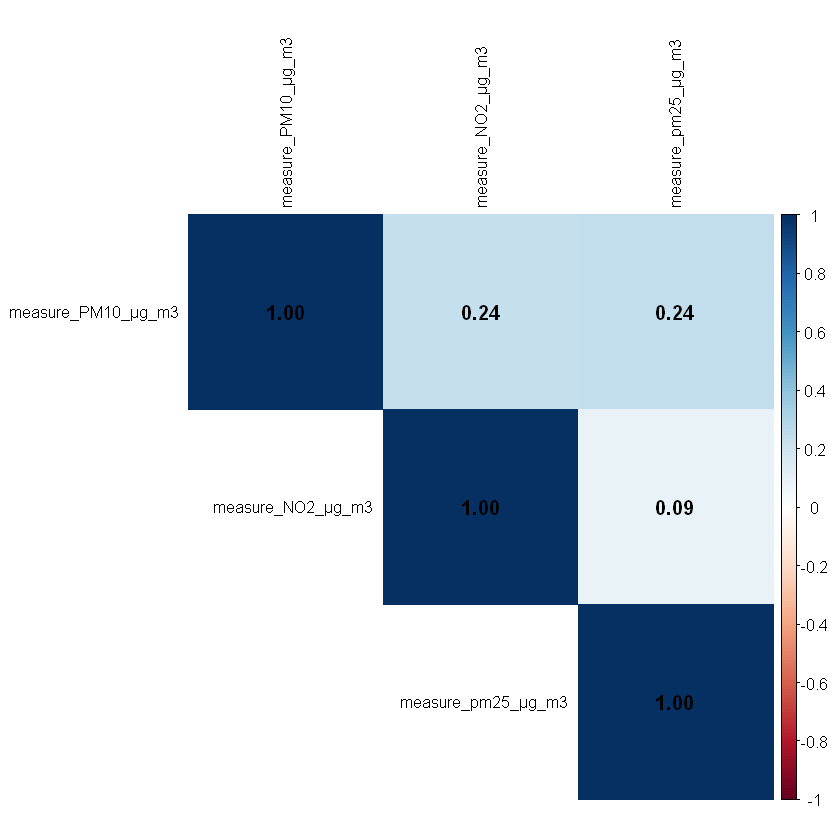

In [23]:
# ====== CORRELATION PAR REGION, année 2019 =====

# Région Afrique

# 1. Filtrer les données de l'année 2019 et de la région "African Region"
data_region <- subset(data, region == "African Region" & measure_year == 2019)

# 2. Calculer le pourcentage de valeurs manquantes par ville pour les trois polluants
city_missing <- aggregate(
  cbind(measure_PM10_μg_m3, measure_NO2_μg_m3, measure_pm25_μg_m3) ~ city,
  data = data_region,
  FUN = function(x) mean(is.na(x)) * 100
)

# 3. Garder les villes où chaque polluant a moins de 10 % de valeurs manquantes
valid_cities <- city_missing$city[
  rowSums(city_missing[, 2:4] < 10) == 3
]

# 4. Filtrer à nouveau les données avec ces villes valides
data_filtered <- subset(data_region, city %in% valid_cities)

# 5. Sélectionner les colonnes numériques à corréler
polluants <- data_filtered[, c("measure_PM10_μg_m3", "measure_NO2_μg_m3", "measure_pm25_μg_m3")]

# 6. Calculer la matrice de corrélation en ignorant les NA
cor_matrix <- cor(polluants, use = "complete.obs")

# 7. Afficher la matrice dans la console
print(cor_matrix)

# 8. Installer et charger le package corrplot si nécessaire
if (!require(corrplot)) install.packages("corrplot")
library(corrplot)

# 9. Sauvegarder le graphique de corrélation dans un fichier PNG
png("corrplot_afrique.png", width = 800, height = 600)
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         addCoef.col = "black",
         tl.cex = 0.8)
dev.off()


# Eastern Mediterranean Region
# 1. Filtrer les données de l'année 2019 et de la région "Eastern Mediterranean Region"
data_region <- subset(data, region == "Eastern Mediterranean Region" & measure_year == 2019)

# 2. Calculer le pourcentage de valeurs manquantes par ville pour les trois polluants
city_missing <- aggregate(
  cbind(measure_PM10_μg_m3, measure_NO2_μg_m3, measure_pm25_μg_m3) ~ city,
  data = data_region,
  FUN = function(x) mean(is.na(x)) * 100
)

# 3. Garder les villes où chaque polluant a moins de 10 % de valeurs manquantes
valid_cities <- city_missing$city[
  rowSums(city_missing[, 2:4] < 10) == 3
]

# 4. Filtrer à nouveau les données avec ces villes valides
data_filtered <- subset(data_region, city %in% valid_cities)

# 5. Sélectionner les colonnes numériques à corréler
polluants <- data_filtered[, c("measure_PM10_μg_m3", "measure_NO2_μg_m3", "measure_pm25_μg_m3")]

# 6. Calculer la matrice de corrélation en ignorant les NA
cor_matrix <- cor(polluants, use = "complete.obs")

# 7. Afficher la matrice dans la console
print(cor_matrix)

# 8. Installer et charger le package corrplot si nécessaire
if (!require(corrplot)) install.packages("corrplot")
library(corrplot)

# 9. le graphique de corrélation 

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         addCoef.col = "black",
         tl.cex = 0.8)


# European Region
# 1. Filtrer les données de l'année 2019 et de la région "European Region"
data_region <- subset(data, region == "European Region" & measure_year == 2019)

# 2. Calculer le pourcentage de valeurs manquantes par ville pour les trois polluants
city_missing <- aggregate(
  cbind(measure_PM10_μg_m3, measure_NO2_μg_m3, measure_pm25_μg_m3) ~ city,
  data = data_region,
  FUN = function(x) mean(is.na(x)) * 100
)



# Filtrage simple en cascade extraire le nouveau dataset "positive_cities"

# Étape 1: Sélectionner les villes de la région Europe
villes_europe <- data[data$region == "European Region", ]

# Étape 2: Garder seulement les années 2017 à 2019
villes_europe_periode <- villes_europe[villes_europe$measure_year >= 2017 & 
                                         villes_europe$measure_year <= 2019, ]


### Dataset retenue

In [27]:
# Étape 3: Garder seulement les lignes où PM10 et NO2 ne sont pas vides
positive_cities <- villes_europe_periode[!is.na(villes_europe_periode$measure_PM10_μg_m3) & 
                                           !is.na(villes_europe_periode$measure_NO2_μg_m3), ]

# Vérification de la nouvelle base de données
print(paste("Nombre de lignes dans positive_cities :", nrow(positive_cities)))
print(paste("Nombre de villes uniques :", length(unique(positive_cities$city))))
print(paste("Nombre de pays uniques :", length(unique(positive_cities$country_name))))

# Affichage des villes et pays
print("Villes sélectionnées :")
print(unique(positive_cities$city))
print("Pays correspondants :")
print(unique(positive_cities$country_name))





[1] "Nombre de lignes dans positive_cities : 5554"
[1] "Nombre de villes uniques : 2062"
[1] "Nombre de pays uniques : 38"
[1] "Villes sélectionnées :"
   [1] "Escaldes-Engordany"              "Amstetten"                      
   [3] "Bad Vöslau"                      "Biedermannsdorf"                
   [5] "Bludenz"                         "Bratislava"                     
   [7] "Braunau Am Inn"                  "Bruck An Der Mur"               
   [9] "Burgfried"                       "Deutschlandsberg"               
  [11] "Donawitz"                        "Dornbirn"                       
  [13] "Eisenstadt"                      "Enns"                           
  [15] "Feldkirch"                       "Freistadt"                      
  [17] "Furstenfeld"                     "Gänserndorf"                    
  [19] "Gemeinde Imst"                   "Gmunden"                        
  [21] "Goss"                            "Graz"                           
  [23] "Graz-Umgebung" 

### exportation du dataframe retenue en fichier csv

In [35]:
write.csv(positive_cities,
          file = "C:/Users/ndiay/Desktop/lptf/projets/IA/DATA_ANALYSIS/R_RSTUDIO/R_U_shiny/positive_cities.csv",
          row.names = FALSE)


### nettoyage du dataset finale

In [60]:
# 📄 Charger le fichier CSV
data <- read.csv("C:/Users/ndiay/Desktop/lptf/projets/IA/DATA_ANALYSIS/R_RSTUDIO/R_U_shiny/positive_cities.csv", stringsAsFactors = FALSE)

# Renommer les colonnes avec standardisation minimale
colnames(data) <- c(
  "region",
  "code_iso3",
  "country_name",
  "city",
  "measure_year",
  "measure_pm25_ug_m3",
  "measure_pm10_ug_m3",
  "measure_no2_ug_m3",
  "pm25_temporal_coverage",
  "pm10_temporal_coverage",
  "no2_temporal_coverage",
  "source",
  "monitoring_station_number",
  "database_version",
  "status"
)

# Vérification
str(data)
#Export du fichier nettoyé
write.csv(data,
          file =  "C:/Users/ndiay/Desktop/lptf/projets/IA/DATA_ANALYSIS/R_RSTUDIO/R_U_shiny/positive_cities_standardized.csv",
          row.names = FALSE)
print(" Export terminé : 'positive_cities_standardized.csv' enregistré avec succès.")

'data.frame':	5554 obs. of  15 variables:
 $ region                   : chr  "European Region" "European Region" "European Region" "European Region" ...
 $ code_iso3                : chr  "AND" "AND" "AND" "AUT" ...
 $ country_name             : chr  "Andorra" "Andorra" "Andorra" "Austria" ...
 $ city                     : chr  "Escaldes-Engordany" "Escaldes-Engordany" "Escaldes-Engordany" "Amstetten" ...
 $ measure_year             : int  2017 2018 2019 2017 2018 2019 2017 2018 2019 2017 ...
 $ measure_pm25_ug_m3       : num  NA NA NA NA NA NA NA NA NA NA ...
 $ measure_pm10_ug_m3       : num  26.3 23.2 24.6 18.9 21.2 ...
 $ measure_no2_ug_m3        : num  28.7 26.6 31 21.1 20.5 ...
 $ pm25_temporal_coverage   : num  NA NA NA NA NA NA NA NA NA NA ...
 $ pm10_temporal_coverage   : num  NA NA NA NA NA NA NA NA NA NA ...
 $ no2_temporal_coverage    : num  95.1 93.4 92.2 95.5 95.1 ...
 $ source                   : chr  "European Environment Agency (downloaded in 2021)" "European Environme

### Dataset supplémentaire

In [ ]:
# Filtrage des villes avec stations de monitoring

# Garder seulement les lignes où monitoring_station_number n'est pas vide
positive_cities_stations <- positive_cities[!is.na(positive_cities$monitoring_station_number), ]

# Vérification de la nouvelle base
print(paste("Nombre de lignes après filtrage stations :", nrow(positive_cities_stations)))
print(paste("Nombre de villes avec stations :", length(unique(positive_cities_stations$city))))
print(paste("Nombre de pays avec stations :", length(unique(positive_cities_stations$country_name))))

# Affichage final des villes et pays
print("Villes avec stations de monitoring :")
print(unique(positive_cities_stations$city))

print("Pays avec stations de monitoring :")
print(unique(positive_cities_stations$country_name))